# Week 4 Day 5

## Returns & Volatility

This notebook compares five stocks using:

- Log Returns
- Annualized Return
- Annualized Volatility
- Sharpe Ratio

Risk-free rate assumed = 6.5%

In [39]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt

In [40]:
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

data = yf.download(
    stocks,
    period="5y",
    auto_adjust=True
)

[*********************100%***********************]  5 of 5 completed


In [41]:
close_prices = data["Close"]

close_prices.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2021-06-21,693.559143,610.537109,1306.719971,1013.290588,2852.701416
2021-06-22,691.276367,610.150269,1316.779907,1008.082092,2877.192871
2021-06-23,692.068237,604.202087,1309.202148,998.842529,2842.503662
2021-06-24,701.735352,613.245239,1358.020264,975.358765,2940.292725
2021-06-25,705.858459,627.704712,1371.084839,953.143127,2946.567871


## Simple Returns vs Log Returns

Simple Return:

R = (Pₜ − Pₜ₋₁) / Pₜ₋₁

Log Return:

ln(Pₜ / Pₜ₋₁)

Log returns are commonly used in quantitative finance because they are additive over time.

In [42]:
log_returns = np.log(
    close_prices /
    close_prices.shift(1)
)

log_returns = log_returns.dropna()

log_returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2021-06-22,-0.003297,-0.000634,0.007669,-0.005153,0.008549
2021-06-23,0.001145,-0.009797,-0.005771,-0.009208,-0.012130
2021-06-24,0.013872,0.014856,0.036610,-0.023792,0.033824
2021-06-25,0.005858,0.023305,0.009574,-0.023040,0.002132
2021-06-28,-0.004465,0.002001,-0.001526,-0.008806,-0.013115


In [43]:
annual_return = (
    log_returns.mean() * 252
)

In [44]:
annual_volatility = (
    log_returns.std()
    * np.sqrt(252)
)

## Sharpe Ratio

Sharpe Ratio measures risk-adjusted return.

Formula:

Sharpe Ratio =
(Annual Return − Risk-Free Rate)
/
Annual Volatility

Risk-Free Rate = 6.5% = 0.065

In [45]:
risk_free_rate = 0.065

sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

In [46]:
results = pd.DataFrame({
    "Annual_Return": annual_return,
    "Annual_Volatility": annual_volatility,
    "Sharpe_Ratio": sharpe_ratio
})

results = results.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

results

,Annual_Return,Annual_Volatility,Sharpe_Ratio
Ticker,,,
ICICIBANK.NS,0.161398,0.202926,0.475042
RELIANCE.NS,0.054793,0.223223,-0.045726
HDFCBANK.NS,0.023366,0.208076,-0.200091
INFY.NS,-0.046157,0.253881,-0.437829
TCS.NS,-0.064482,0.219124,-0.590905


In [47]:
results["Rank"] = range(
    1,
    len(results) + 1
)

results

,Annual_Return,Annual_Volatility,Sharpe_Ratio,Rank
Ticker,,,,
ICICIBANK.NS,0.161398,0.202926,0.475042,1
RELIANCE.NS,0.054793,0.223223,-0.045726,2
HDFCBANK.NS,0.023366,0.208076,-0.200091,3
INFY.NS,-0.046157,0.253881,-0.437829,4
TCS.NS,-0.064482,0.219124,-0.590905,5


## Sharpe Ratio Ranking

Higher Sharpe Ratio indicates better risk-adjusted performance.

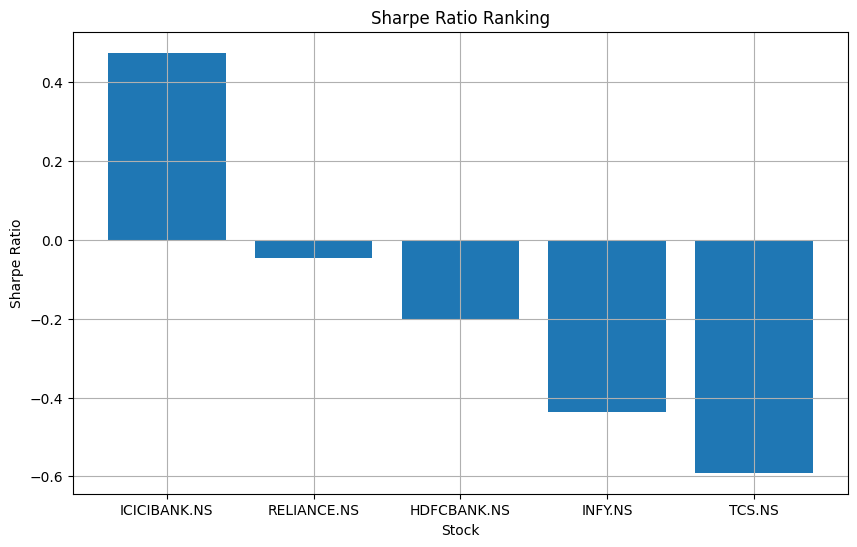

In [48]:
plt.figure(figsize=(10,6))

plt.bar(
    results.index,
    results["Sharpe_Ratio"]
)

plt.title(
    "Sharpe Ratio Ranking"
)

plt.xlabel("Stock")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.savefig(
    "../images/sharpe_ratio_chart.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Interpretation

The Sharpe Ratio compares return relative to risk.

A higher Sharpe Ratio indicates that a stock generated more return per unit of volatility.

Among the selected stocks, the highest-ranked stock delivered the best risk-adjusted performance during the analysis period. Stocks with lower Sharpe Ratios either produced lower returns or experienced higher volatility.

Investors often prefer assets with higher Sharpe Ratios because they provide better compensation for the risk taken.